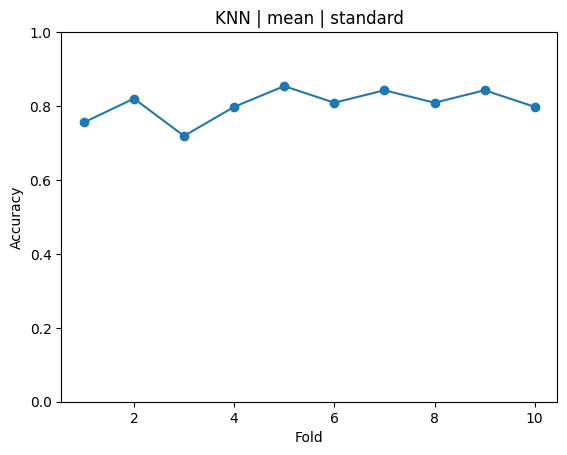

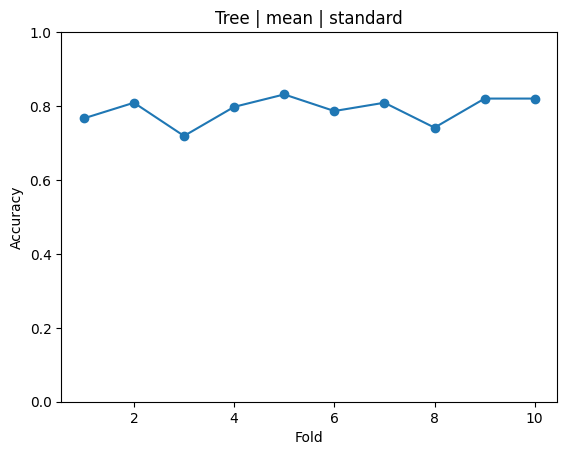

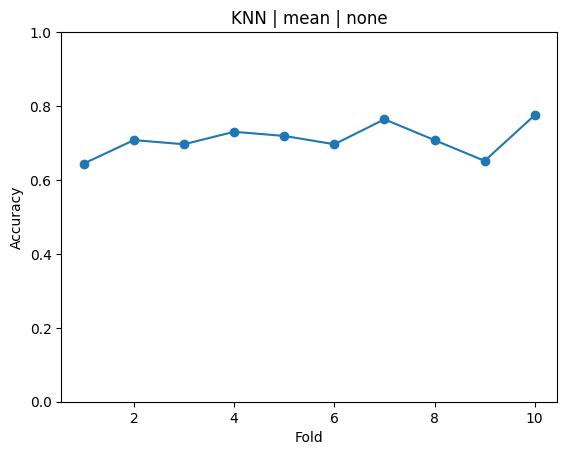

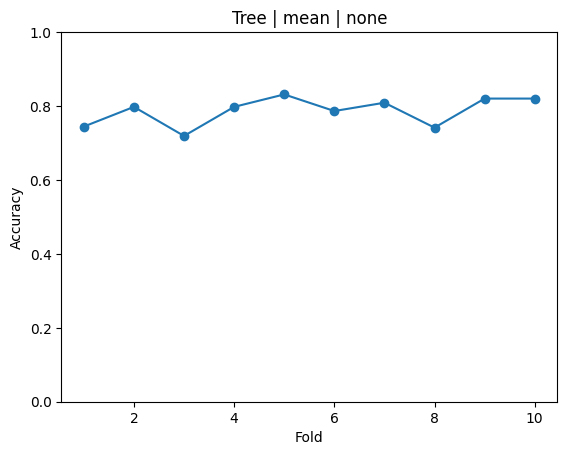

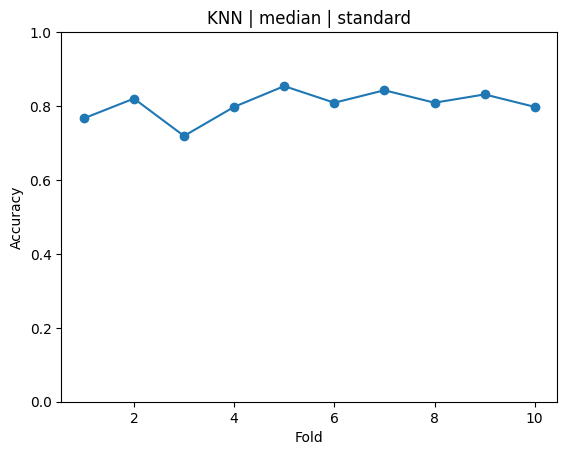

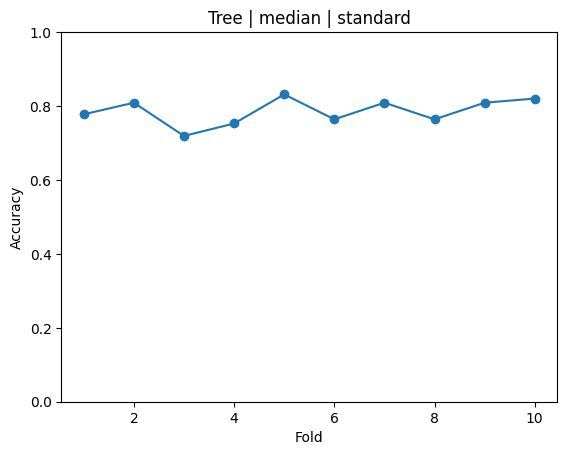

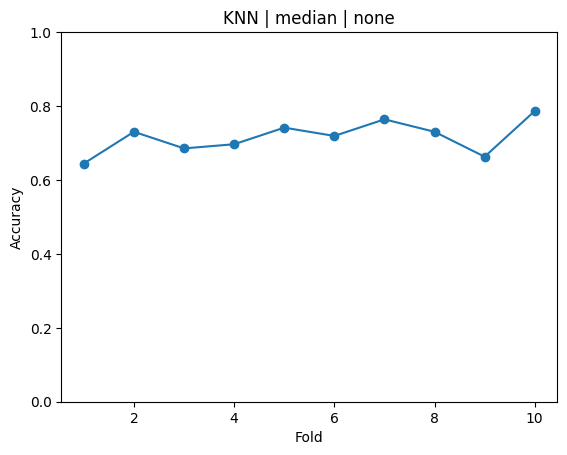

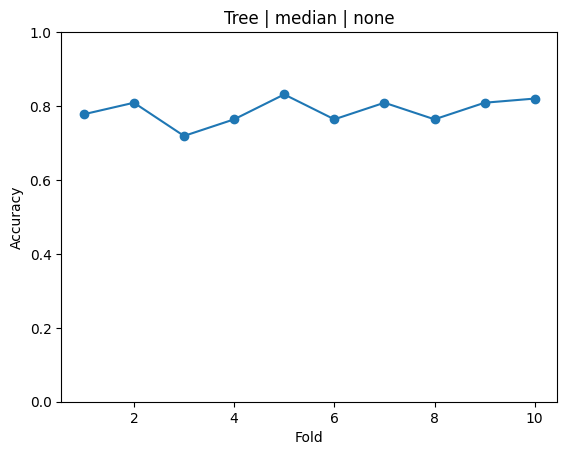

Best KNN params: {'model__n_neighbors': 28, 'model__weights': 'uniform'}
Best KNN score: 0.818227215980025


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv("titanic.csv")

X = df[["Age", "SibSp", "Parch", "Fare", "Pclass", "Sex", "Embarked"]]
y = df["Survived"]

num_cols = ["Age", "SibSp", "Parch", "Fare"]
cat_cols = ["Pclass", "Sex", "Embarked"]

imputations = ["mean", "median"]
scalings = ["standard", "none"]

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Tree": DecisionTreeClassifier(random_state=42)
}

results = []

for imp in imputations:
    for scale in scalings:
        for model_name, model in models.items():

            num_steps = [("imputer", SimpleImputer(strategy=imp))]

            if scale == "standard":
                num_steps.append(("scaler", StandardScaler()))

            num_pipe = Pipeline(num_steps)

            cat_pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ])

            preprocessor = ColumnTransformer([
                ("num", num_pipe, num_cols),
                ("cat", cat_pipe, cat_cols)
            ])

            pipe = Pipeline([
                ("prep", preprocessor),
                ("model", model)
            ])

            scores = cross_val_score(pipe, X, y, cv=10, scoring="accuracy")

            results.append((imp, scale, model_name, scores))

            label = f"{model_name} | {imp} | {scale}"

            plt.figure()
            plt.plot(range(1, 11), scores, marker="o")
            plt.ylim(0, 1)
            plt.title(label)
            plt.xlabel("Fold")
            plt.ylabel("Accuracy")
            plt.show()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", KNeighborsClassifier())
])

param_grid = {
    "model__n_neighbors": list(range(1, 31)),
    "model__weights": ["uniform", "distance"]
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X, y)

print("Best KNN params:", grid.best_params_)
print("Best KNN score:", grid.best_score_)

Accuracy: 0.8100558659217877

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

ROC-AUC: 0.8539525691699605


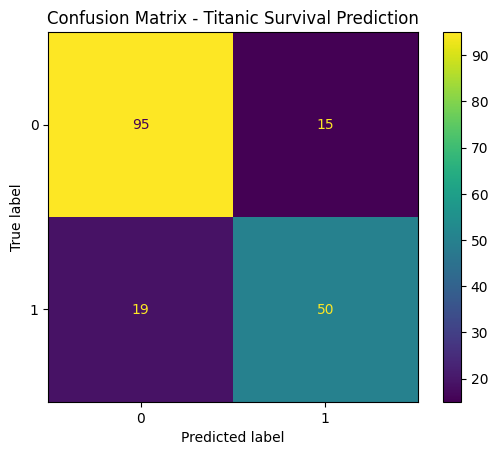

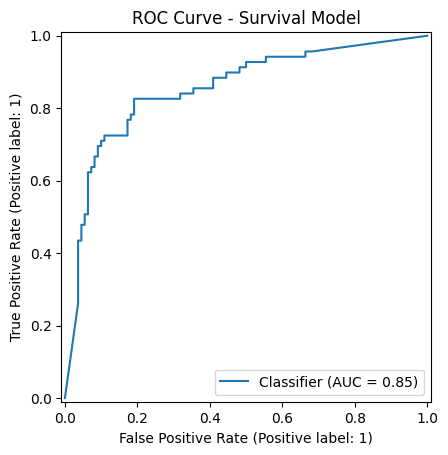

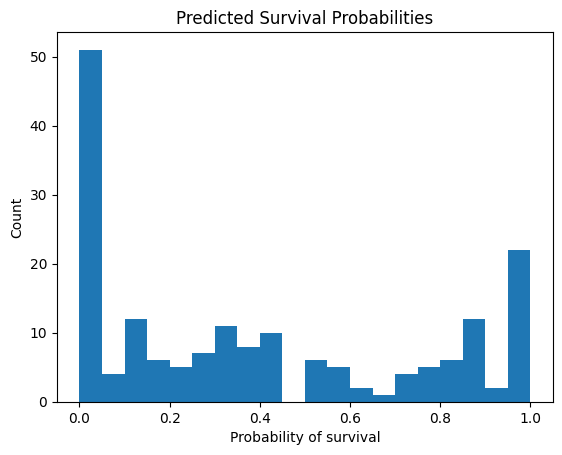

In [31]:
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

model = KNeighborsClassifier(n_neighbors=7, weights="distance")

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Titanic Survival Prediction")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Survival Model")
plt.show()

plt.hist(y_proba, bins=20)
plt.title("Predicted Survival Probabilities")
plt.xlabel("Probability of survival")
plt.ylabel("Count")
plt.show()

In [ ]:
The final model was trained using a K-Nearest Neighbors classifier with hyperparameters selected through cross-validation and grid search. The best configuration used 28 neighbors with uniform weighting.

The model achieved an average cross-validation accuracy of approximately 0.82, meaning it correctly predicts survival in about 8 out of 10 cases on unseen data splits.

This indicates that the model performs reasonably well, but it is not perfect. The relatively high value of k suggests that the model relies on a broader neighborhood of passengers rather than very local patterns. This helps reduce noise and makes predictions more stable across different data splits.

However, the model still makes mistakes, which can be seen in the confusion between survivors and non-survivors. This is expected, since survival depends on complex and partially missing information (e.g. social status, age, gender, and class interactions).

## Decision Tree: Overfitting vs Underfitting

For each `max_depth` value we record:
- **Train accuracy** — how well the model fits training data
- **Test accuracy** — how well it generalizes to unseen data
- **CV accuracy** — most reliable estimate (5-fold cross-validation)

The gap between train and test accuracy reveals whether the tree is overfitting or underfitting.

In [ ]:
depths = range(1, 20)
train_scores = []
test_scores = []
cv_scores = []

for depth in depths:
    dt_num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    dt_cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])
    dt_preprocessor = ColumnTransformer([
        ("num", dt_num_pipe, num_cols),
        ("cat", dt_cat_pipe, cat_cols)
    ])

    pipe = Pipeline([
        ("prep", dt_preprocessor),
        ("model", DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])

    pipe.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, pipe.predict(X_train)))
    test_scores.append(accuracy_score(y_test, pipe.predict(X_test)))

    cv = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
    cv_scores.append(cv.mean())

import numpy as np

plt.figure(figsize=(12, 6))
plt.plot(depths, train_scores, marker="o", label="Train accuracy", color="steelblue")
plt.plot(depths, test_scores,  marker="o", label="Test accuracy",  color="tomato")
plt.plot(depths, cv_scores,    marker="o", label="CV accuracy (5-fold)", color="green", linestyle="--")

best_depth = list(depths)[np.argmax(cv_scores)]
best_score = max(cv_scores)
plt.axvline(x=best_depth, color="gray", linestyle=":", linewidth=1.5)
plt.annotate(
    f"Best depth = {best_depth}\nCV score = {best_score:.3f}",
    xy=(best_depth, best_score),
    xytext=(best_depth + 1, best_score - 0.03),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="gray")
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Underfitting vs Overfitting (Titanic)")
plt.legend()
plt.xticks(list(depths))
plt.ylim(0.6, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best max_depth by CV: {best_depth}")
print(f"Best CV accuracy:     {best_score:.4f}")

In [ ]:
dt_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
dt_cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
dt_preprocessor = ColumnTransformer([
    ("num", dt_num_pipe, num_cols),
    ("cat", dt_cat_pipe, cat_cols)
])

dt_pipe = Pipeline([
    ("prep", dt_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

param_grid = {
    "model__max_depth":         [2, 3, 4, 5, 6, 7, 8, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf":  [1, 2, 4, 8],
    "model__criterion":         ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    dt_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(X, y)

print("Best params:", dt_grid.best_params_)
print("Best CV accuracy:", dt_grid.best_score_)

In [32]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("tips")

X = df.drop(columns=["tip"])
y = df["tip"]

num_cols = ["total_bill", "size"]
cat_cols = ["sex", "smoker", "day", "time"]

Best params: {'model__n_neighbors': 29, 'model__weights': 'distance'}
Best score (neg MSE): -1.1997467066373795
MAE: 0.6911138014462131
MSE: 0.7455327069122512
R2: 0.40356016181351706


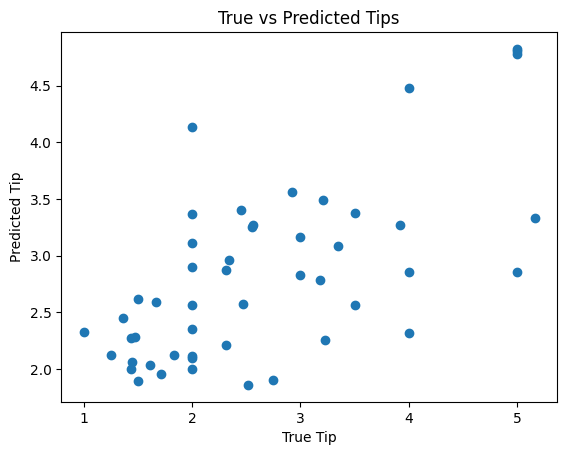

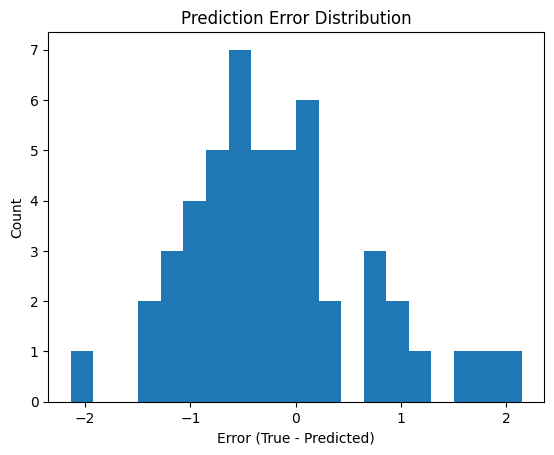

In [35]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])
pipe = Pipeline([
    ("prep", preprocessor),
    ("model", KNeighborsRegressor())
])

param_grid = {
    "model__n_neighbors": list(range(1, 31)),
    "model__weights": ["uniform", "distance"]
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=10,
    scoring="neg_mean_squared_error"
)

grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best score (neg MSE):", grid.best_score_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

plt.scatter(y_test, y_pred)
plt.xlabel("True Tip")
plt.ylabel("Predicted Tip")
plt.title("True vs Predicted Tips")
plt.show()

errors = y_test - y_pred

plt.hist(errors, bins=20)
plt.title("Prediction Error Distribution")
plt.xlabel("Error (True - Predicted)")
plt.ylabel("Count")
plt.show()



In [ ]:
The model was trained to predict restaurant tip amounts using a regression approach on the Seaborn Tips dataset. A pipeline was created that included missing value imputation, feature scaling, and categorical encoding.

K-Nearest Neighbors regression was selected and optimized using grid search with cross-validation. The best configuration was selected based on minimizing prediction error.

In [ ]:
Possible improvements: Feature engineering + advanced models

In [36]:
df = sns.load_dataset("diamonds")

df.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [37]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


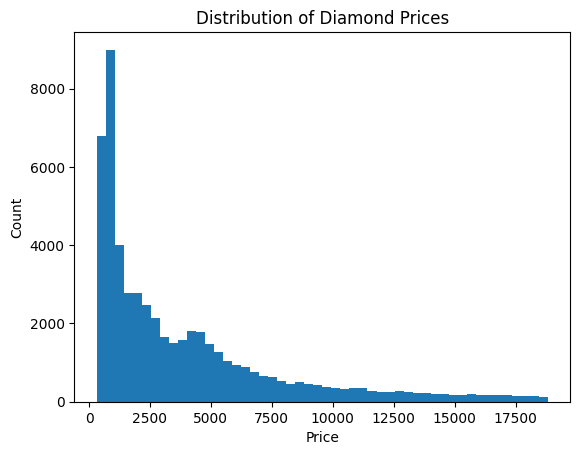

In [38]:
plt.hist(df["price"], bins=50)
plt.title("Distribution of Diamond Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

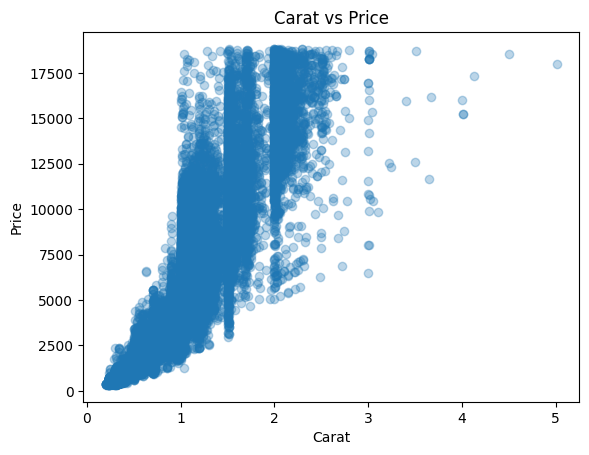

In [39]:
plt.scatter(df["carat"], df["price"], alpha=0.3)
plt.title("Carat vs Price")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()

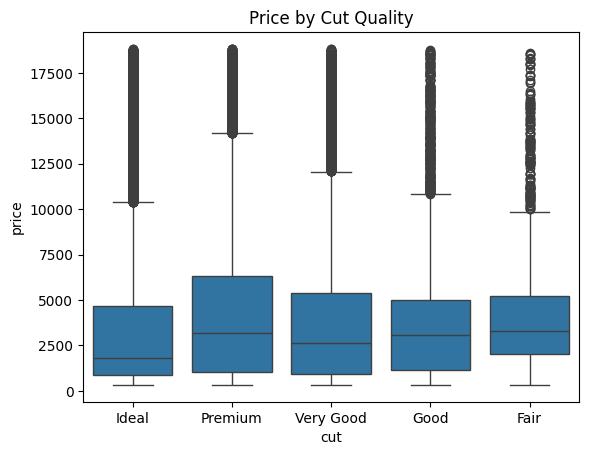

In [40]:
sns.boxplot(x="cut", y="price", data=df)
plt.title("Price by Cut Quality")
plt.show()

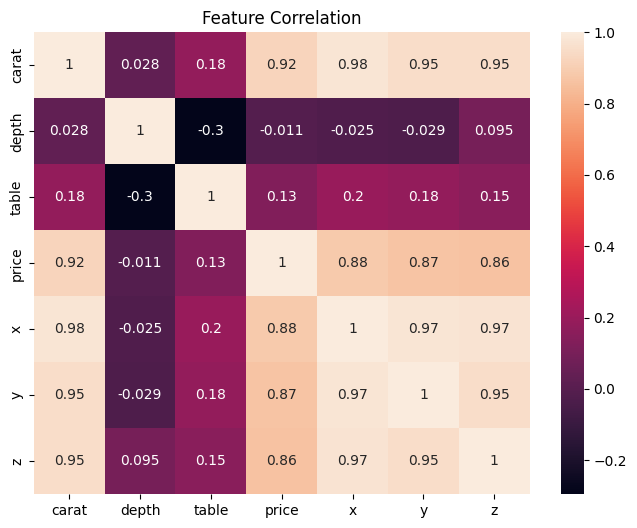

In [41]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation")
plt.show()

MAE: 270.1552311283554
R2: 0.9809316814784846


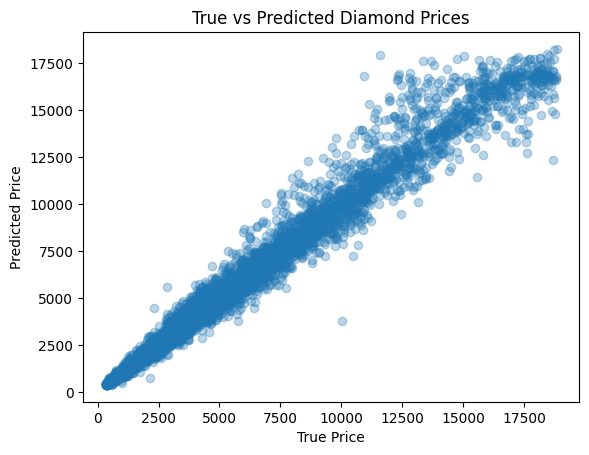

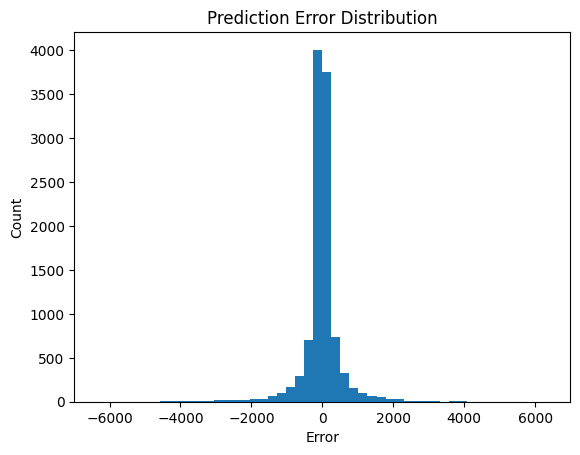

In [43]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=["price"])
y = df["price"]
num_cols = ["carat", "depth", "table", "x", "y", "z"]
cat_cols = ["cut", "color", "clarity"]
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

model = RandomForestRegressor(n_estimators=100, random_state=42)

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", model)
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2:", r2)

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("True vs Predicted Diamond Prices")
plt.show()

errors = y_test - y_pred

plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()

In [ ]:
The Random Forest regression model was trained to predict diamond prices using physical and categorical characteristics. The pipeline included preprocessing steps such as missing value handling, scaling of numerical variables, and encoding of categorical features.

The model achieved a strong R² score, indicating that it explains a large proportion of the variance in diamond prices.